# Installing the pynusinov package

In [ ]:
! python3 -m pip install pynusinov

# Modeling the HeI line intensity using HeI1984 & HeI1992 models

In [ ]:
import pandas as pd
from pynusinov import Euvn1984, Euvn1992

# (1) Loading AE-E data (with auto-datetime)
AEE = pd.read_csv('https://tinyurl.com/aee-data', parse_dates=['time'])

# (2) Scaling He I 58.4 nm flux values (column 'hei_adj')
AEE['hei'] = AEE['hei_adj'] * 1.E13

# (3) Loading OMNI F10.7 data (with auto-datetime)
F10_7 = pd.read_csv('https://tinyurl.com/omni-data', parse_dates=['time'])

# (4) Filtering F10.7 data to match the AEE observations
F10_7 = F10_7[(F10_7['time'] >= '1977-07-01') &
              (F10_7['time'] <= '1981-06-11')]

# (5) Merging AEE and F10_7 observations by timestamp
data = pd.merge(AEE, F10_7, on='time', how='inner')[['time', 'f107','hei']]

# (6) Calculating time-shift from the 21st solar cycle start, in years
cycle21st_start = pd.to_datetime('1976-06-01')
time_shift = (data['time'] - cycle21st_start).dt.days / 365.

# (7) HeI1984 & HeI1992 modeling
HeI_84 = Euvn1984.HeI1984.predict(f107=data['f107'].to_numpy()
                                  , t=time_shift.to_numpy())
HeI_92 = Euvn1992.HeI1992.predict(f107=data['f107'].to_numpy()
                                  , t=time_shift.to_numpy())

# Plotting HeI1984 & HeI1992 model results against AE-E data

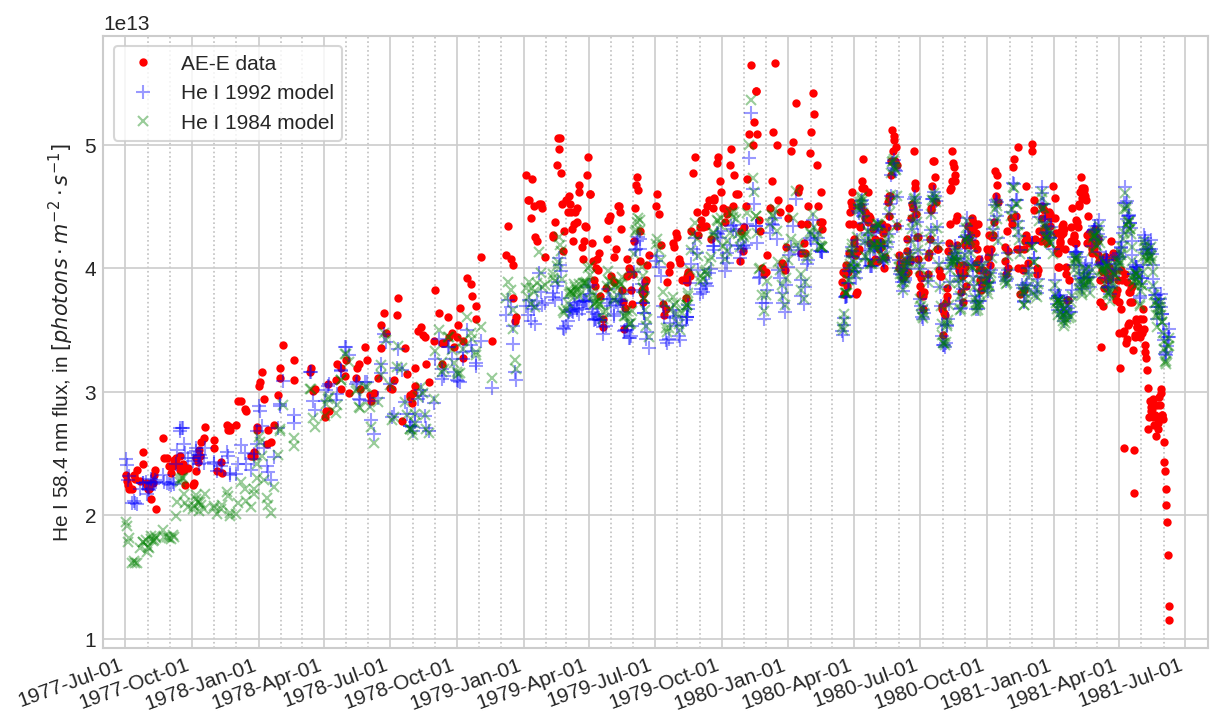

In [ ]:
from matplotlib import pyplot as plt, dates as mdates

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9.5, 6), dpi=150)

# (8) Plotting He I observations vs HeI1984 & HeI1992 model data
ax.plot(data['time'], data['hei'], 'or', ms=3, label='AE-E data')
ax.plot(data['time'], HeI_92, '+b', ms=7, alpha=0.4, label='He I 1992 model')
ax.plot(data['time'], HeI_84, 'xg', ms=5, alpha=0.4, label='He I 1984 model')

ax.set_xlim(pd.to_datetime('1977-06-01'), pd.to_datetime('1981-08-01'))
ax.set_ylabel(r'He I 58.4 nm flux, in $[photons\cdot m^{-2}\cdot s^{-1}]$')
ax.legend(loc='upper left', frameon=True)

# (9) Fine-tuning timestamp / x-axis visualization
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b-%d'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.grid(which='minor', axis='x', color='silver', ls=':', lw=0.8)

fig.autofmt_xdate(rotation=20, ha='right')
plt.show()

# Modeling the $I_{0.8-2}$ band intensity using the I082 model

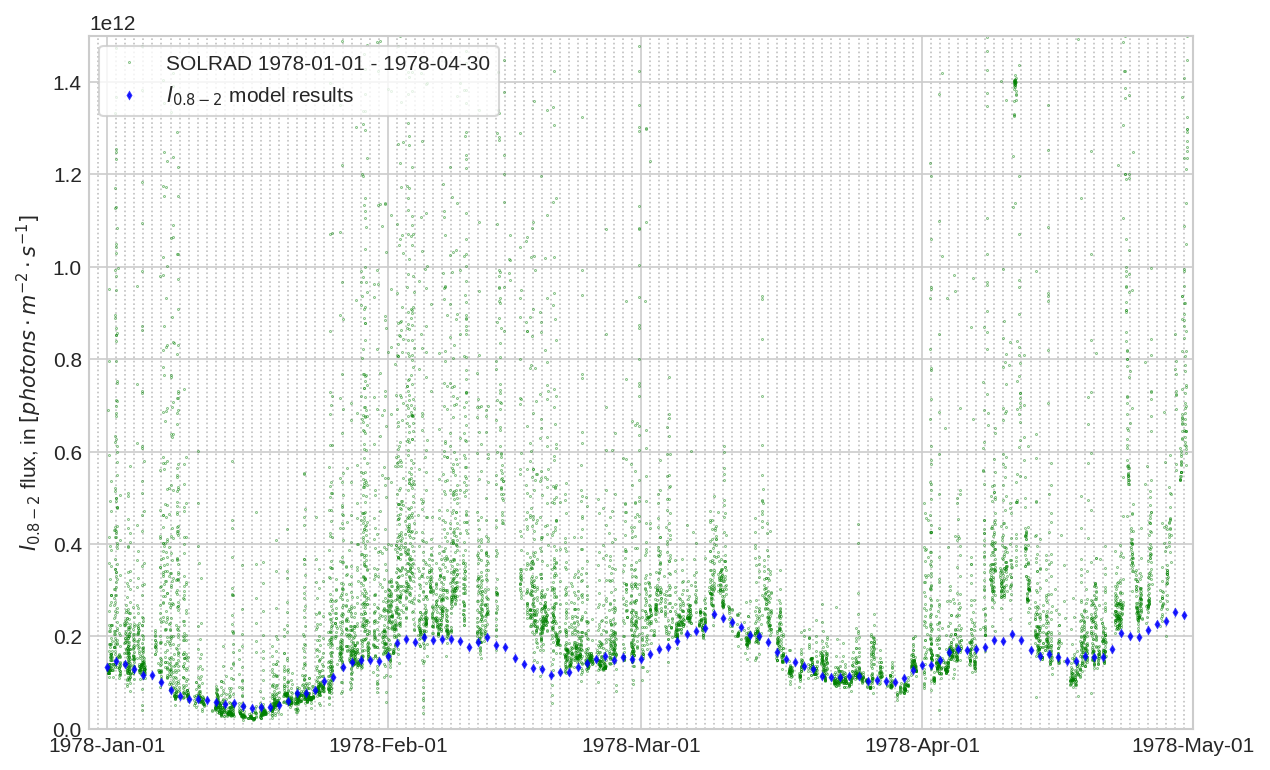

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib import dates as mdates
from pynusinov import Xuvn1992

# (1) Loading F10.7 & SOLRAD observations (with dates)
F10_7 = pd.read_csv('https://tinyurl.com/i082-data'
                     , parse_dates=['time'])[['time', 'f107']]
solrad = pd.read_csv('https://tinyurl.com/sr-1978'
                     , parse_dates=['time'])

# (2) Modeling 0.8-2 [nm] flux for the given F10.7 values
i082_modeled = Xuvn1992.I082.predict(f107=F10_7['f107'].to_numpy())

# (3) Plotting SOLRAD observations vs I082 model results
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9.5, 6), dpi=150)

ax.plot(solrad['time'], solrad['i082_ph_flux']
         , 'og', ms=0.2, label='SOLRAD 1978-01-01 - 1978-04-30')
ax.plot(F10_7['time'], i082_modeled, 'db', ms=2, alpha=0.8
         , label='$I_{0.8-2}$ model results')

# (4) Fine-tuning timestamp / x-axis visualization
ax.set_xlim(pd.to_datetime('1977-12-30'), pd.to_datetime('1978-05-01'))
ax.set_ylim(0, 1.5E12)
ax.set_ylabel(r'$I_{0.8-2}$ flux, in $[photons\cdot m^{-2}\cdot s^{-1}]$')
ax.legend(loc='upper left', frameon=True)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b-%d'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))
ax.grid(which='minor', axis='x', color='silver', ls=':', lw=0.8)
plt.show()